Accuracy Evaluation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

# Load dataset
df = pd.read_csv("/content/HIHD.csv")

# Select relevant features based on the rule-based approach
features = ["smv", "ax_std", "ay_std", "az_std"]
X = df[features]
y = df["label"]

In [ ]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
# Print evaluation metrics
print(f"✅ Decision Tree Accuracy: {accuracy:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

✅ Decision Tree Accuracy: 0.9143

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        55
           1       0.74      0.93      0.82        15

    accuracy                           0.91        70
   macro avg       0.86      0.92      0.88        70
weighted avg       0.93      0.91      0.92        70



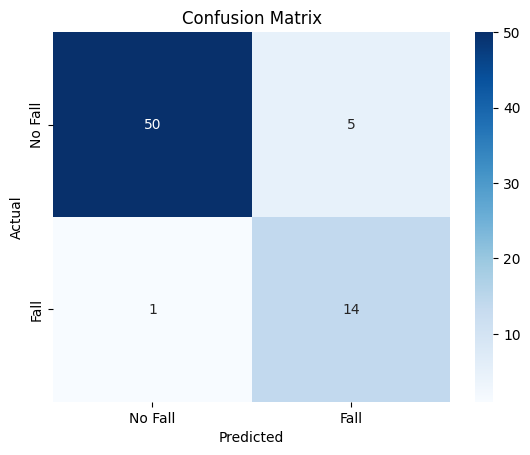

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Fall", "Fall"], yticklabels=["No Fall", "Fall"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Data Visualization

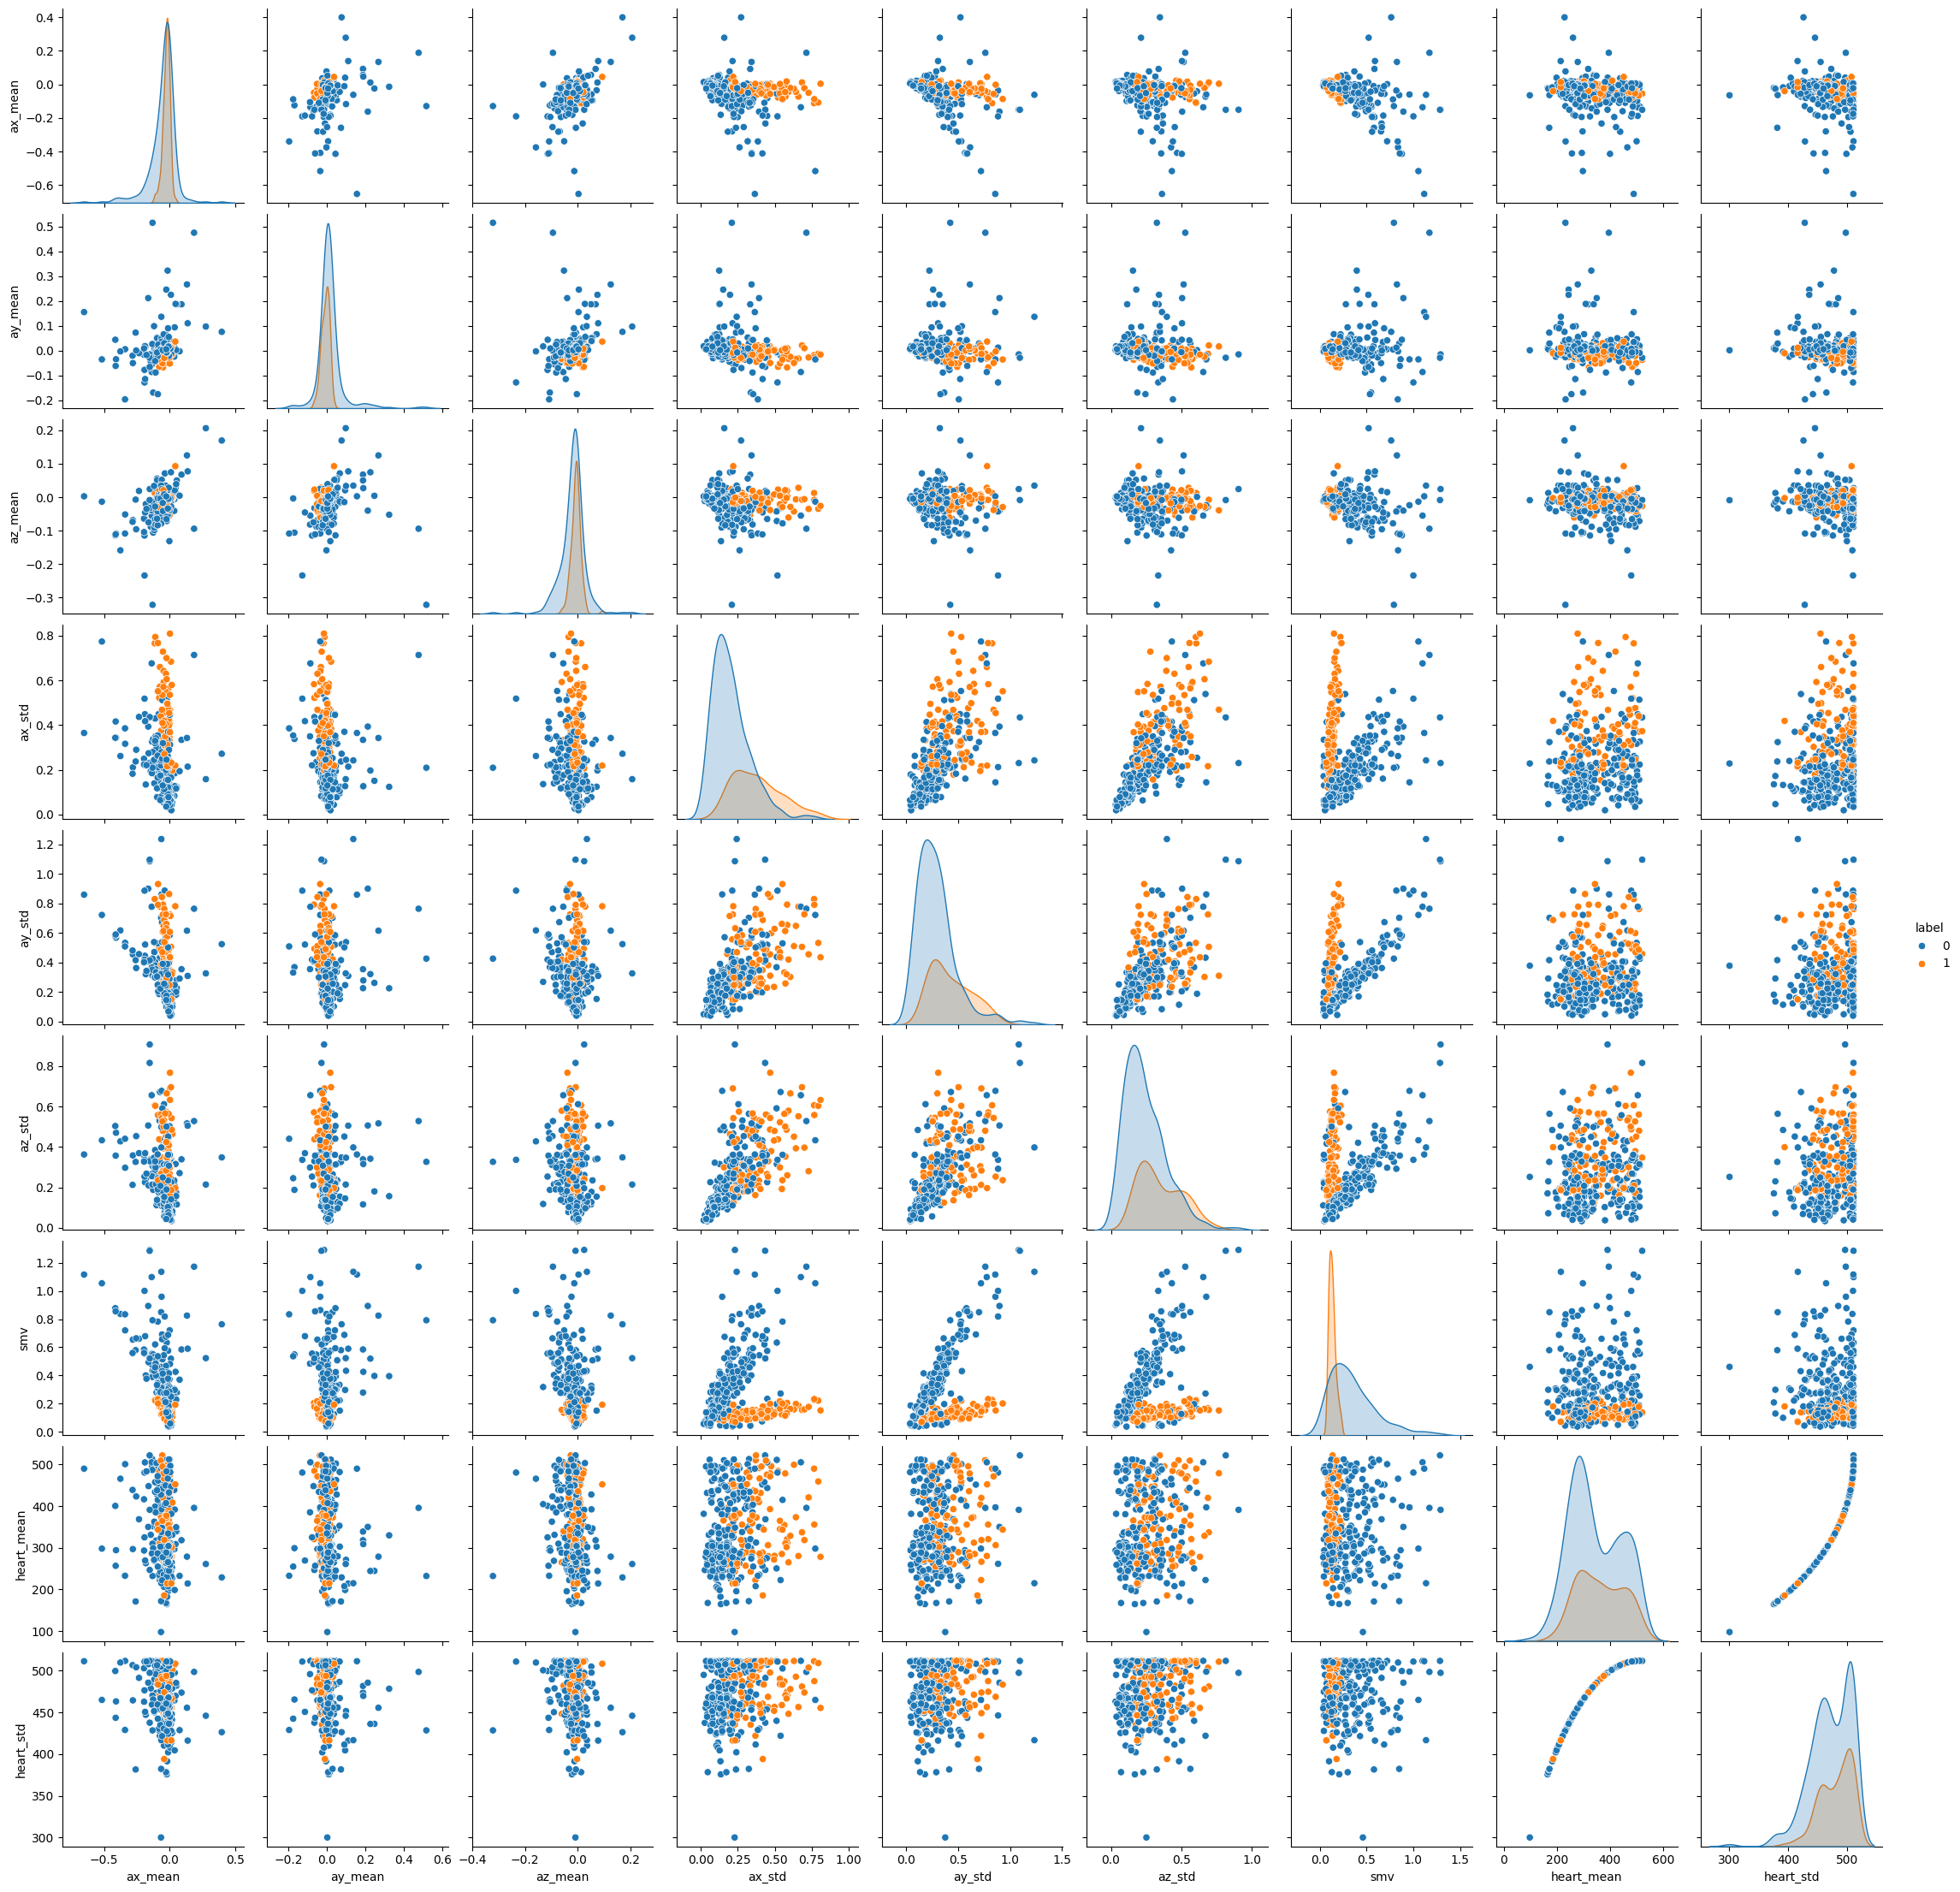

In [ ]:
# 1️⃣ Dataset Overview
sns.pairplot(df, hue="label", diag_kind="kde")
plt.show()

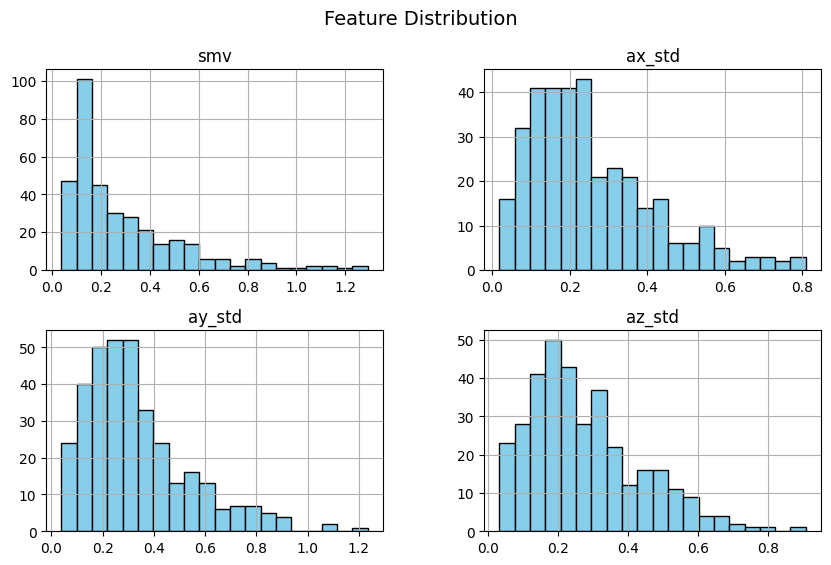

In [ ]:
# 2️⃣ Feature Distribution
df[features].hist(figsize=(10, 6), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Feature Distribution", fontsize=14)
plt.show()

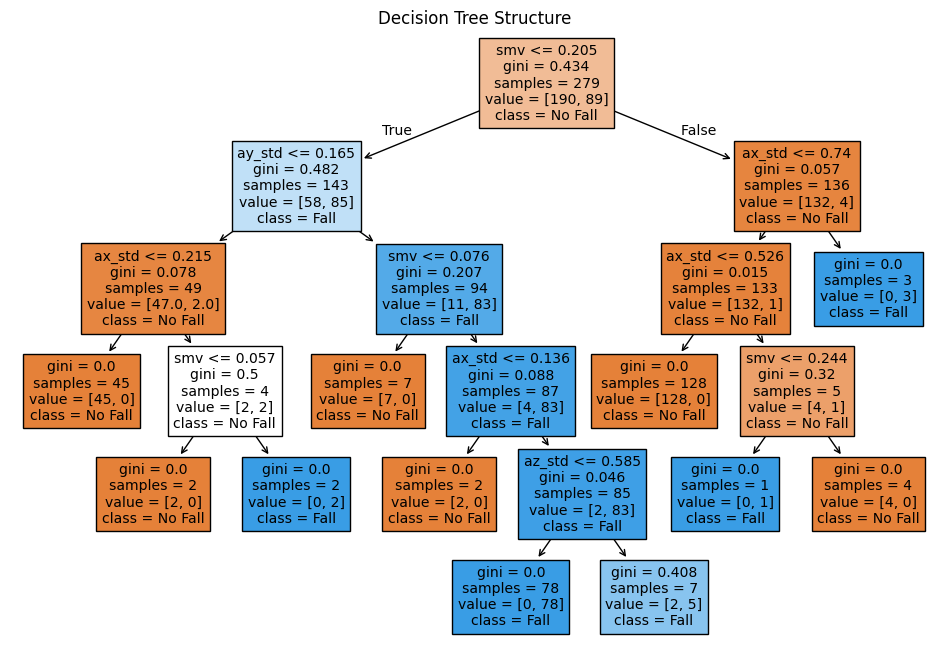

In [ ]:
# 3️⃣ Decision Tree Structure
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=features, class_names=["No Fall", "Fall"], filled=True)
plt.title("Decision Tree Structure")
plt.show()

In [ ]:
# 4️⃣ Train Random Forest for Comparison
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 5️⃣ Compare Decision Tree vs. Random Forest
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Accuracy: 0.9429


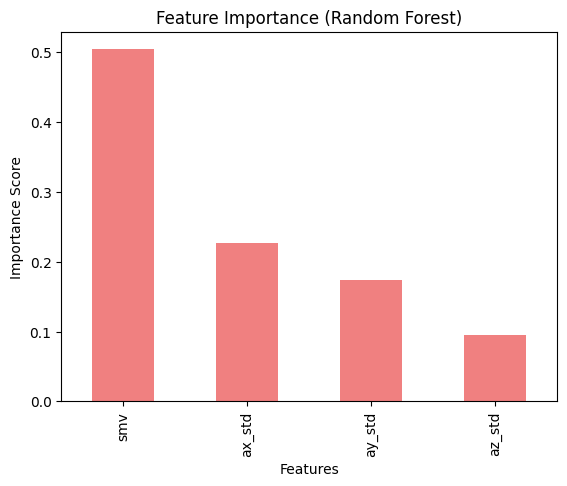

In [ ]:
# 6️⃣ Feature Importance from Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
feature_importance.plot(kind="bar", color="lightcoral")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

Prediction using Unseen Data

In [ ]:
import numpy as np

# Define some hypothetical unseen test cases (assumed based on dataset patterns)
unseen_data = pd.DataFrame({
    "smv": [-0.85, -0.50, 0.30, 1.20, -0.65],
    "ax_std": [0.15, -0.40, 0.75, 1.10, -0.10],
    "ay_std": [-0.90, 0.20, 0.50, -0.30, 0.85],
    "az_std": [-1.00, 0.60, -0.10, 1.50, -0.25],
})

In [ ]:
# Make predictions using the trained decision tree model
unseen_predictions = dt_model.predict(unseen_data)

# Add predictions to the dataframe
unseen_data["Predicted_Label"] = unseen_predictions

In [ ]:
# Convert predicted labels to "Fall" (1) or "No Fall" (0)
unseen_data["Predicted_Label"] = unseen_data["Predicted_Label"].map({0: "No Fall", 1: "Fall"})

# Display predictions
print("🔍 Predictions for Unseen Data:")
print(unseen_data)

🔍 Predictions for Unseen Data:
    smv  ax_std  ay_std  az_std Predicted_Label
0 -0.85    0.15   -0.90   -1.00         No Fall
1 -0.50   -0.40    0.20    0.60         No Fall
2  0.30    0.75    0.50   -0.10            Fall
3  1.20    1.10   -0.30    1.50            Fall
4 -0.65   -0.10    0.85   -0.25         No Fall


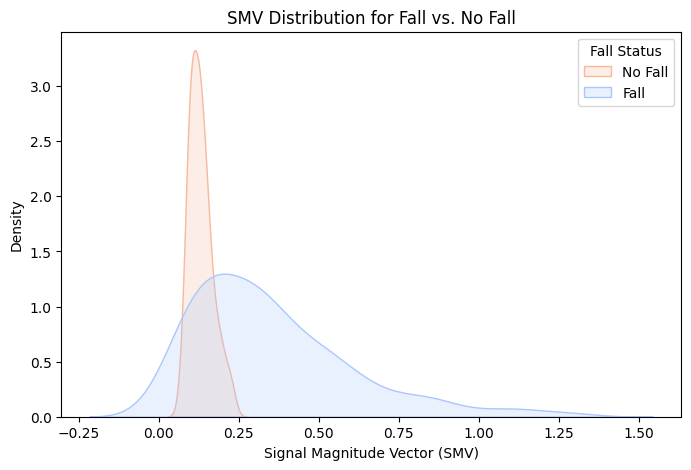

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a histogram with KDE for Fall vs. No Fall
plt.figure(figsize=(8, 5))

sns.kdeplot(data=df, x="smv", hue="label", fill=True, palette="coolwarm")
plt.title("SMV Distribution for Fall vs. No Fall")
plt.xlabel("Signal Magnitude Vector (SMV)")
plt.ylabel("Density")
plt.legend(title="Fall Status", labels=["No Fall", "Fall"])
plt.show()

`Data cleaning & Feature Selection`

In [ ]:
import pandas as pd

# Load dataset
file_path = "/content/HIHD.csv"  # Update with the correct path if needed
df = pd.read_csv(file_path)


# Display basic info and first few rows
print(df.info())  # Check data types and missing values
print(df.head())  # Preview the first few rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ax_mean     349 non-null    float64
 1   ay_mean     349 non-null    float64
 2   az_mean     349 non-null    float64
 3   ax_std      349 non-null    float64
 4   ay_std      349 non-null    float64
 5   az_std      349 non-null    float64
 6   smv         349 non-null    float64
 7   heart_mean  349 non-null    float64
 8   heart_std   349 non-null    float64
 9   label       349 non-null    int64  
 10  subject     349 non-null    object 
 11  scenario    349 non-null    object 
dtypes: float64(9), int64(1), object(2)
memory usage: 32.8+ KB
None
    ax_mean   ay_mean   az_mean    ax_std    ay_std    az_std       smv  \
0 -0.006456  0.015697 -0.005218  0.138422  0.177580  0.175156  0.126316   
1 -0.009429  0.014384  0.002540  0.302549  0.301892  0.457241  0.110524   
2 -0.073081 -0.031897  0.027

In [ ]:
# Remove unnecessary columns
########################################################if we remove heart , remove it from here
df_cleaned = df.drop(columns=["subject", "scenario"])

# Save cleaned data for further processing
df_cleaned.to_csv("cleaned_HIHD.csv", index=False)

# Display the cleaned dataset
print(df_cleaned.head())

    ax_mean   ay_mean   az_mean    ax_std    ay_std    az_std       smv  \
0 -0.006456  0.015697 -0.005218  0.138422  0.177580  0.175156  0.126316   
1 -0.009429  0.014384  0.002540  0.302549  0.301892  0.457241  0.110524   
2 -0.073081 -0.031897  0.027922  0.659727  0.777050  0.551743  0.185769   
3  0.015812 -0.026233 -0.030156  0.219743  0.244459  0.542286  0.131484   
4 -0.020766 -0.036805 -0.020855  0.253118  0.330738  0.310635  0.117544   

   heart_mean   heart_std  label  
0  291.212121  461.633513      1  
1  256.666667  443.499969      1  
2  280.152416  456.191348      1  
3  278.476940  455.337791      1  
4  447.486293  507.478566      1  


`Feature Selection`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# Load cleaned dataset
df = pd.read_csv("cleaned_HIHD.csv")

# Separate features and labels
X = df.drop(columns=["label"])
y = df["label"]

In [ ]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest to check feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

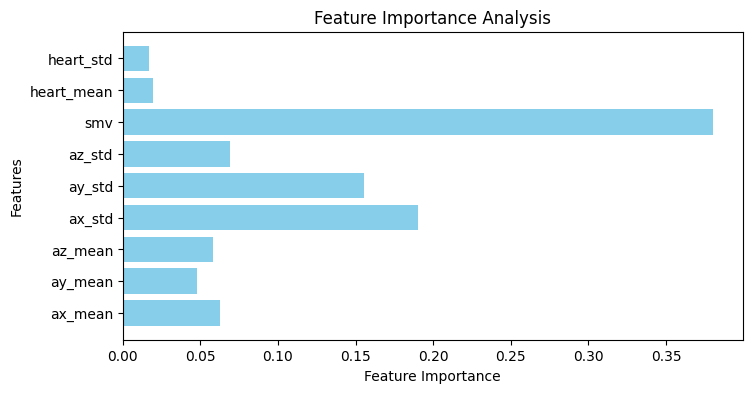

In [ ]:
# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Plot feature importance
plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance Analysis")
plt.show()

`Data Preprocessing`

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("HIHD.csv")

In [ ]:
# Select only important features
selected_features = ["smv", "ax_std", "ay_std", "az_std", "label"]
df = df[selected_features]

# Check for NaN values
print("Missing values:\n", df.isnull().sum())

Missing values:
 smv       0
ax_std    0
ay_std    0
az_std    0
label     0
dtype: int64


In [ ]:
# Normalize the features (Standardization)
scaler = StandardScaler()
df[["smv", "ax_std", "ay_std", "az_std"]] = scaler.fit_transform(df[["smv", "ax_std", "ay_std", "az_std"]])

# Save processed dataset
df.to_csv("processed_dataset.csv", index=False)

print("✅ Data Preprocessing Completed! Processed dataset saved.")
print(df.head())

✅ Data Preprocessing Completed! Processed dataset saved.
        smv    ax_std    ay_std    az_std  label
0 -0.683243 -0.726707 -0.756092 -0.635504      1
1 -0.750229  0.290364 -0.150551  1.152470      1
2 -0.431049  2.503739  2.164024  1.751458      1
3 -0.661320 -0.222775 -0.430316  1.691521      1
4 -0.720451 -0.015954 -0.010037  0.223216      1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Load the processed dataset
df = pd.read_csv("processed_dataset.csv")

# Split data into features & labels
X = df.drop(columns=["label"])
y = df["label"]

In [ ]:
# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest Model
model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42)

In [ ]:
# Predictions on test data
y_pred = model.predict(X_test)

# Evaluate the model
print("✅ Model Training Complete!")
print(f"🎯 Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

✅ Model Training Complete!
🎯 Accuracy: 0.9429
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        55
           1       0.82      0.93      0.88        15

    accuracy                           0.94        70
   macro avg       0.90      0.94      0.92        70
weighted avg       0.95      0.94      0.94        70



`Convert the Random Forest to a Decision Tree`

In [ ]:
import joblib
from sklearn.tree import export_text

In [ ]:
import joblib

# Save the trained Random Forest model first, as it was not saved previously
# The 'model' variable is available from the previous training step.
joblib.dump(model, "fall_detection_model.pkl")

# Load trained Random Forest model
rf_model = joblib.load("fall_detection_model.pkl")

# Extract the best performing tree
best_tree = rf_model.estimators_[0]  # Pick the first tree

In [ ]:
# Print the tree structure
tree_rules = export_text(best_tree, feature_names=["smv", "ax_std", "ay_std", "az_std"])
print(tree_rules)

|--- ax_std <= 0.29
|   |--- smv <= -0.76
|   |   |--- smv <= -0.93
|   |   |   |--- class: 0.0
|   |   |--- smv >  -0.93
|   |   |   |--- az_std <= -1.13
|   |   |   |   |--- class: 0.0
|   |   |   |--- az_std >  -1.13
|   |   |   |   |--- ay_std <= -0.98
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- ay_std >  -0.98
|   |   |   |   |   |--- class: 1.0
|   |--- smv >  -0.76
|   |   |--- ay_std <= 1.04
|   |   |   |--- smv <= -0.71
|   |   |   |   |--- ay_std <= -0.77
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- ay_std >  -0.77
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- smv >  -0.71
|   |   |   |   |--- class: 0.0
|   |   |--- ay_std >  1.04
|   |   |   |--- smv <= 0.65
|   |   |   |   |--- class: 1.0
|   |   |   |--- smv >  0.65
|   |   |   |   |--- class: 0.0
|--- ax_std >  0.29
|   |--- smv <= 0.12
|   |   |--- az_std <= 1.96
|   |   |   |--- ax_std <= 0.50
|   |   |   |   |--- ay_std <= -0.58
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- a

In [ ]:
# Save the tree as a text file for reference
with open("decision_tree_rules.txt", "w") as f:
    f.write(tree_rules)

print("✅ Decision Tree Extracted & Saved!")

✅ Decision Tree Extracted & Saved!


In [ ]:

import math
def calculate_smv(accel):
    ax, ay, az = accel['x'], accel['y'], accel['z']
    return math.sqrt(ax**2 + ay**2 + az**2)

In [ ]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
import math
import joblib

# تحميل الموديل مرة واحدة
model = joblib.load("fall_detection_model.pkl")
scaler = joblib.load("scaler.pkl")


def calculate_magnitude(x, y, z):
    return math.sqrt(x*x + y*y + z*z)


def calculate_std(values):
    if len(values) == 0:
        return 0
    mean = sum(values) / len(values)
    variance = sum((x - mean)**2 for x in values) / len(values)
    return math.sqrt(variance)


def predict_from_accel(accel_x, accel_y, accel_z):
    """
    accel_x, accel_y, accel_z = lists (لازم يكون فيهم عدد قيم كفاية زي 20)
    """

    # ===== نفس الحسابات بالظبط =====

    # STD
    ax_std = calculate_std(accel_x)
    ay_std = calculate_std(accel_y)
    az_std = calculate_std(accel_z)

    # آخر قيمة
    ax = accel_x[-1]
    ay = accel_y[-1]
    az = accel_z[-1]

    # SMV
    smv = calculate_magnitude(ax, ay, az) - 1.0

    # ===== أهم حاجة: ترتيب الفيتشرز الصح =====
    features = [[smv, ax_std, ay_std, az_std]]

    print("Features:", features)  # للـ debug

    # Scaling
    features_scaled = scaler.transform(features)

    # Prediction
    prediction = model.predict(features_scaled)

    return float(prediction[0])

In [ ]:
accel_x = [1,1,1,1,4,3,2,1,0.5,0.3,0.2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1]
accel_y = [0,0,0,0,2,1,0.5,0.2,0.1,0,0,0,0,0,0,0,0,0,0,0]
accel_z = [1,1,1,1,5,4,3,2,1,1,1,1,1,1,1,1,1,1,1,1]

print(predict_from_accel(accel_x, accel_y, accel_z))

Features: [[0.00498756211208895, 1.044736808961951, 0.4784349485562275, 1.118033988749895]]
1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
accel_x = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
accel_y = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
accel_z = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

print(predict_from_accel(accel_x, accel_y, accel_z))

Features: [[0.41421356237309515, 0.0, 0.0, 0.0]]
0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
accel_x = [1,2,1.5,2.2,1.8,2.5,1.7,2.0,1.6,2.1,1.9,2.3,1.8,2.0,1.7,2.2,1.9,2.1,1.8,2.0]
accel_y = [0.5,1.0,0.8,1.2,0.9,1.3,0.7,1.1,0.8,1.0,0.9,1.2,0.8,1.1,0.7,1.0,0.9,1.1,0.8,1.0]
accel_z = [1,1.5,1.2,1.8,1.3,2.0,1.4,1.7,1.2,1.6,1.3,1.9,1.4,1.6,1.2,1.8,1.3,1.7,1.4,1.6]

print(predict_from_accel(accel_x, accel_y, accel_z))

Features: [[1.749545416973504, 0.3153965757582032, 0.19339079605813717, 0.2616772821625905]]
0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
accel_x = [1,-2,1.5,-2.2,1.8,-2.5,1.7,-2.0,1.6,-2.1,1.9,-2.3,1.8,-2.0,1.7,-2.2,1.9,-2.1,1.8,-2.0]
accel_y = [0.5,-1.0,0.8,-1.2,0.9,-1.3,0.7,-1.1,0.8,-1.0,0.9,-1.2,0.8,-1.1,0.7,-1.0,0.9,-1.1,0.8,-1.0]
accel_z = [1,1.5,1.2,1.8,1.3,2.0,1.4,1.7,1.2,1.6,1.3,1.9,1.4,1.6,1.2,1.8,1.3,1.7,1.4,1.6]

print(predict_from_accel(accel_x, accel_y, accel_z))

Features: [[1.749545416973504, 1.9165789835015932, 0.946255779374689, 0.2616772821625905]]
0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
accel_x = [1,-2,1.5,-2.2,5.5,-4.5,2.0,0.5,0.1,0.0,0.1,0.0,0.1,0.0,0.1,0.0,0.1,0.0,0.1,0.0]
accel_y = [0.5,-1.0,0.8,-1.2,4.0,-3.0,1.5,0.2,0.1,0.0,0.1,0.0,0.1,0.0,0.1,0.0,0.1,0.0,0.1,0.0]
accel_z = [1,1.5,1.2,1.8,8.0,3.0,2.0,1.2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0]

print(predict_from_accel(accel_x, accel_y, accel_z))

Features: [[0.0, 1.8249931506720785, 1.232720568498798, 1.551217263957567]]
1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
accel_x = [0.1, 0.12, 0.08, 0.1, 0.11, 0.09, 0.1, 0.1, 0.12, 0.08,
           0.1, 0.11, 0.09, 0.1, 0.1, 0.12, 0.08, 0.1, 0.11, 0.09]

accel_y = [-0.3, -0.28, -0.32, -0.3, -0.29, -0.31, -0.3, -0.3, -0.28, -0.32,
           -0.3, -0.29, -0.31, -0.3, -0.3, -0.28, -0.32, -0.3, -0.29, -0.31]

accel_z = [9.7, 9.72, 9.68, 9.7, 9.71, 9.69, 9.7, 9.7, 9.72, 9.68,
           9.7, 9.71, 9.69, 9.7, 9.7, 9.72, 9.68, 9.7, 9.71, 9.69]

print(predict_from_accel(accel_x, accel_y, accel_z))

Features: [[8.695375186139007, 0.01224744871391589, 0.012247448713915888, 0.012247448713916281]]
0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(model.feature_names_in_)

['smv' 'ax_std' 'ay_std' 'az_std']


In [ ]:
import numpy as np
import math
import joblib
import pandas as pd

# تحميل الموديل
model = joblib.load("fall_detection_model.pkl")
scaler = joblib.load("scaler.pkl")


def predict_from_accel(accel_x, accel_y, accel_z):

    # ---------------------------
    # 1. حساب magnitude (SMV)
    # ---------------------------
    def calculate_magnitude(x, y, z):
        return math.sqrt(x*x + y*y + z*z)

    # ---------------------------
    # 2. حساب std
    # ---------------------------
    def calculate_std(values):
        mean = sum(values) / len(values)
        variance = sum((x - mean)**2 for x in values) / len(values)
        return math.sqrt(variance)

    # ---------------------------
    # 3. حساب الفيتشرز
    # ---------------------------
    ax_std = calculate_std(accel_x)
    ay_std = calculate_std(accel_y)
    az_std = calculate_std(accel_z)

    # آخر قيمة
    ax = accel_x[-1]
    ay = accel_y[-1]
    az = accel_z[-1]

    # SMV (زي ما كنتي عاملة بالظبط)
    smv = calculate_magnitude(ax, ay, az) - 9.7   # 👈 مهم جدًا (نشيل الجاذبية)

    # ---------------------------
    # 4. نحطهم بنفس ترتيب الموديل
    # ---------------------------
    features = pd.DataFrame(
        [[smv, ax_std, ay_std, az_std]],
        columns=['smv', 'ax_std', 'ay_std', 'az_std']
    )

    print("Features before scaling:", features)

    # ---------------------------
    # 5. نعمل scaling
    # ---------------------------
    features_scaled = scaler.transform(features)

    # ---------------------------
    # 6. prediction
    # ---------------------------
    prediction = model.predict(features_scaled)

    return float(prediction[0])

In [ ]:
accel_x = [0.1, 0.2, -0.1, 2.5, -3.0, 1.0, 0.2, 0.1, 0.0, 0.1]*2
accel_y = [-0.3, -0.2, -0.4, 2.0, -2.5, 0.8, 0.2, 0.1, 0.0, 0.1]*2
accel_z = [9.7, 9.8, 9.6, 14.0, 6.0, 9.0, 9.7, 9.7, 9.7, 9.7]*2

print(predict_from_accel(accel_x, accel_y, accel_z))

Features before scaling:         smv    ax_std  ay_std   az_std
0  0.001031  1.274716    1.06  1.80801
1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [48]:
accel_x = [0.1, 0.12, 0.08, 0.1, 0.11, 0.09, 0.1, 0.1, 0.12, 0.08,
           0.1, 0.11, 0.09, 0.1, 0.1, 0.12, 0.08, 0.1, 0.11, 0.09]

accel_y = [-0.3, -0.28, -0.32, -0.3, -0.29, -0.31, -0.3, -0.3, -0.28, -0.32,
           -0.3, -0.29, -0.31, -0.3, -0.3, -0.28, -0.32, -0.3, -0.29, -0.31]

accel_z = [9.7, 9.72, 9.68, 9.7, 9.71, 9.69, 9.7, 9.7, 9.72, 9.68,
           9.7, 9.71, 9.69, 9.7, 9.7, 9.72, 9.68, 9.7, 9.71, 9.69]

print(predict_from_accel(accel_x, accel_y, accel_z))

Features before scaling:         smv    ax_std    ay_std    az_std
0 -0.004625  0.012247  0.012247  0.012247
0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
